In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import rbo

import networkx as nx

def repel_labels(ax, x, y, labels, k=0.01):
    G = nx.DiGraph()
    data_nodes = []
    init_pos = {}
    for xi, yi, label in zip(x, y, labels):
        data_str = 'data_{0}'.format(label)
        G.add_node(data_str)
        G.add_node(label)
        G.add_edge(label, data_str)
        data_nodes.append(data_str)
        init_pos[data_str] = (xi, yi)
        init_pos[label] = (xi, yi)

    pos = nx.spring_layout(G, pos=init_pos, fixed=data_nodes, k=k)

    # undo spring_layout's rescaling
    pos_after = np.vstack([pos[d] for d in data_nodes])
    pos_before = np.vstack([init_pos[d] for d in data_nodes])
    scale, shift_x = np.polyfit(pos_after[:,0], pos_before[:,0], 1)
    scale, shift_y = np.polyfit(pos_after[:,1], pos_before[:,1], 1)
    shift = np.array([shift_x, shift_y])
    for key, val in pos.items():
        pos[key] = (val*scale) + shift

    for label, data_str in G.edges():
        ax.annotate(label,
                    xy=pos[data_str], xycoords='data',
                    xytext=pos[label], textcoords='data',
                    arrowprops=dict(arrowstyle="->",
                                    shrinkA=0, shrinkB=0,
                                    connectionstyle="arc3",
                                    color='red'), )
    # expand limits
    # all_pos = np.vstack(pos.values())
    # x_span, y_span = np.ptp(all_pos, axis=0)
    # mins = np.min(all_pos-x_span*0.15, 0)
    # maxs = np.max(all_pos+y_span*0.15, 0)
    # ax.set_xlim([mins[0], maxs[0]])
    # ax.set_ylim([mins[1], maxs[1]])
    x1, x2= ax.get_xlim()
    ax.set_xlim(x1*1.3, x2*1.3)

    x1, x2= ax.get_ylim()
    ax.set_ylim(x1*1.3, x2*1.3)

from scipy.stats import spearmanr


In [2]:
sc_scores=dict()
st_scores=dict()

for sample in ["CID4290", "CID4465", "CID4535", "CID44971"]:
    print("-"*20, sample, "-"*20)

    adata_st=sc.read_h5ad("out/"+sample+"stf_results_tfa_only.h5ad")
    adata_sc=sc.read_h5ad("out/"+sample+"_sc_tfa_only.h5ad")

    sc.pp.scale(adata_sc)
    sc.pp.scale(adata_st)

    var_names=np.intersect1d(adata_sc.var_names,adata_st.var_names)
    adata_sc=adata_sc[:,var_names]
    adata_st=adata_st[:,var_names]

    cts=np.intersect1d(adata_st.obsm['celltype_major'].columns,adata_sc.obs['celltype_major'].unique())

    adata_st.varm['ct_scores'] = pd.DataFrame(
        np.linalg.pinv(adata_st.obsm['celltype_major']).dot(adata_st.to_df()).T,
        index=adata_st.var_names,
        columns=adata_st.obsm['celltype_major'].columns
    )
    adata_st.varm['ct_scores_stl'] = pd.DataFrame(
        np.linalg.pinv(adata_st.obsm['celltype_major']).dot(adata_st.to_df('stl_tfa')).T,
        index=adata_st.var_names,
        columns=adata_st.obsm['celltype_major'].columns
    )
    adata_sc.varm['ct_scores']=adata_sc.to_df().groupby(adata_sc.obs['celltype_major']).mean().T

    print(pd.DataFrame({ "sc vs stl":
                       {ct: round(spearmanr(adata_sc.varm['ct_scores'][ct], adata_st.varm['ct_scores_stl'][ct])[0],2)
                        for ct in cts},
                   "sc vs stan":{ct:  round(spearmanr(adata_sc.varm['ct_scores'][ct], adata_st.varm['ct_scores'][ct])[0],2)
                                 for ct in cts}}))


    for ct in cts:
        if sc_scores.get(ct) is None:
            sc_scores[ct]=dict()
        if st_scores.get(ct) is None:
            st_scores[ct]=dict()
        sc_scores[ct][sample]=adata_sc.varm['ct_scores'][ct]
        st_scores[ct][sample]=adata_st.varm['ct_scores'][ct]


-------------------- CID4290 --------------------
                   sc vs stl  sc vs stan
B-cells                 0.18        0.44
CAFs                    0.29        0.51
Cancer Epithelial       0.28        0.28
Endothelial             0.22        0.57
Myeloid                 0.18        0.41
Normal Epithelial      -0.21       -0.21
PVL                     0.25        0.58
T-cells                 0.05        0.33
-------------------- CID4465 --------------------
                   sc vs stl  sc vs stan
B-cells                 0.06        0.14
CAFs                    0.35        0.43
Cancer Epithelial       0.26        0.56
Endothelial             0.27        0.26
Myeloid                 0.33        0.45
Normal Epithelial       0.18        0.19
PVL                     0.10        0.17
Plasmablasts            0.02        0.17
T-cells                 0.19        0.35
-------------------- CID4535 --------------------
                   sc vs stl  sc vs stan
B-cells                 0.17  

In [43]:
print("spearmanr                    ",
      spearmanr(adata_sc.varm['ct_scores'][ct], adata_st.varm['ct_scores'][ct]))
print("spearmanr vs random ranking  ",
      spearmanr(adata_sc.varm['ct_scores'][ct], np.random.permutation(218)))

print("rbo                          ",
      rbo.RankingSimilarity(adata_st.varm['ct_scores'][ct].rank().to_list(),adata_sc.varm['ct_scores'][ct].rank().to_list()).rbo())
print("rbo vs random ranking        ",
      rbo.RankingSimilarity(adata_sc.varm['ct_scores'][ct].rank().to_list(), np.random.permutation(218)).rbo())

spearmanr                     SpearmanrResult(correlation=0.5584249210474039, pvalue=2.841331617683872e-19)
spearmanr vs random ranking   SpearmanrResult(correlation=0.005122579950181534, pvalue=0.9400558631052638)
rbo                           0.48225115592031864
rbo vs random ranking         0.5176197815391579


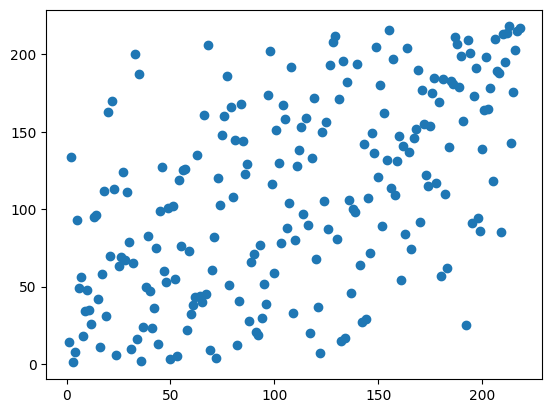

In [38]:
plt.plot(adata_st.varm['ct_scores'][ct].rank().to_list(),adata_sc.varm['ct_scores'][ct].rank().to_list(), 'o')

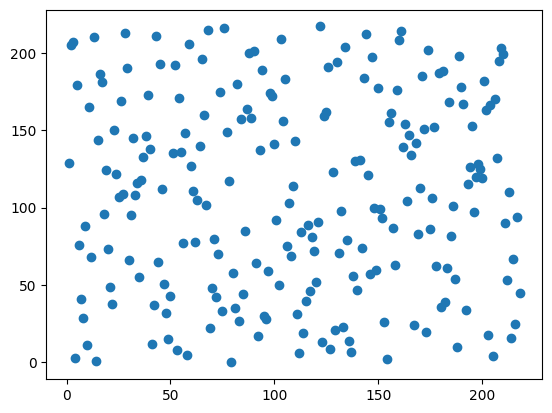

In [39]:
plt.plot(adata_st.varm['ct_scores'][ct].rank().to_list(), np.random.permutation(218), 'o')

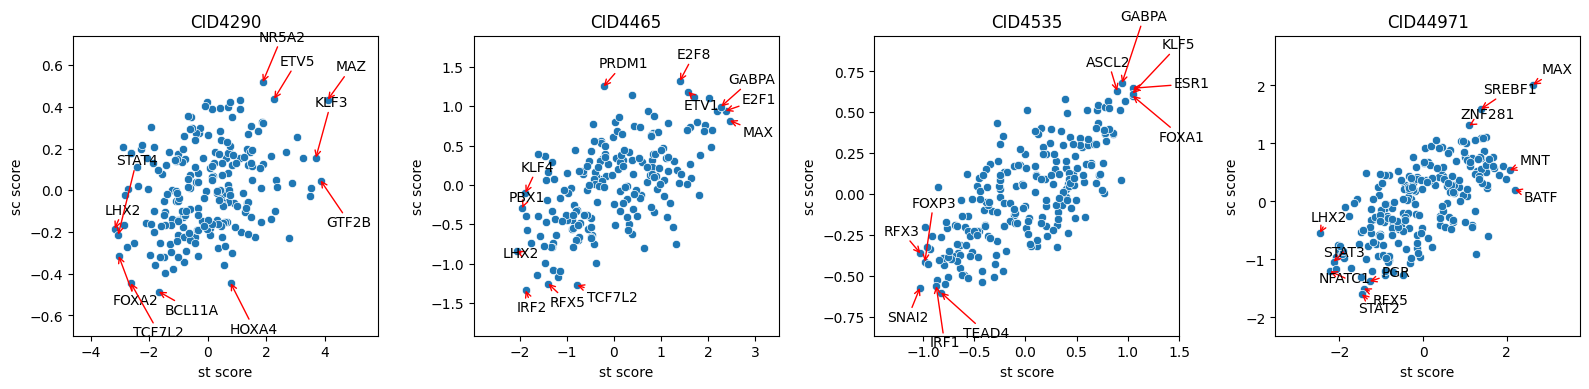

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

In [3]:
ct="Cancer Epithelial"
fig, axs=plt.subplots(1,4, figsize=(16,4))
for ax,sample in zip(axs, st_scores[ct].keys()):
    x=st_scores[ct][sample]
    y=sc_scores[ct][sample]
    plt.figure(figsize=(5,5))
    _=sns.scatterplot(x=x,y=y, ax=ax)
    ax.set_xlabel("st score")
    ax.set_ylabel("sc score")
    ax.set_title(sample)

    tfs=np.unique([*x.sort_values().tail(3).index.to_list(),
                   *x.sort_values().head(3).index.to_list(),
                   *y.sort_values().tail(3).index.to_list(),
                   *y.sort_values().head(3).index.to_list()])
    repel_labels(ax, x.loc[tfs].to_numpy(), y.loc[tfs].to_numpy(), tfs, k=0.2)
fig.tight_layout()

In [33]:
df2.T

,AHR,AR,ARID3A,ARNT,ARNTL,ASCL2,ATF1,ATF2,ATF3,BACH1,...,ZKSCAN1,ZNF12,ZNF143,ZNF217,ZNF236,ZNF250,ZNF263,ZNF281,ZNF384,ZNF76
B-cells,0.804045,0.034371,-2.015535,-0.321296,0.493450,1.266008,-0.715671,2.646930,0.154827,-0.621863,...,-0.141255,0.445515,-1.154639,0.779482,-0.220825,0.921728,0.233282,-0.931221,0.909797,0.442325
CAFs,-0.538955,-0.395658,0.148283,0.437770,-0.288532,-0.634132,0.267771,0.166760,0.025483,-0.116655,...,-1.027357,-0.651906,-0.087922,-0.509926,-0.514390,-0.977733,-0.178537,0.590345,-1.179383,0.232226
Cancer Epithelial,-0.439486,-0.555320,-0.488215,1.473789,-1.125947,1.216132,0.423825,-0.135512,0.738067,0.746465,...,-0.430337,0.372053,0.432211,-0.451143,0.978396,0.657345,0.284956,2.032291,0.623722,1.111471
Endothelial,0.015983,0.040050,1.488211,0.215387,-0.139900,0.093792,-0.075686,0.530965,-0.450132,-0.222387,...,0.560382,0.987484,-1.013951,-0.901119,-0.789529,-1.992157,2.068019,-0.252394,-0.995862,2.149688
Myeloid,-0.221302,0.126193,-0.180374,-0.801805,-0.664698,-0.411739,-1.321231,0.216337,0.907439,-0.681940,...,0.687011,-0.616740,0.834728,-1.115131,-0.380422,-1.577545,0.725109,-0.626601,0.344288,0.844491
Normal Epithelial,-0.094643,0.494364,0.888151,1.959011,-0.964356,1.130635,1.529686,0.262382,-0.448986,-0.164642,...,-1.375134,0.661389,-0.071541,-0.500297,-0.449289,1.737399,-0.118975,0.471095,-1.264396,0.462775
PVL,-0.611291,-1.061065,-0.563511,0.223277,-0.408873,-0.656391,-0.132201,0.610437,0.539703,0.795211,...,-0.320210,0.311061,-0.055067,0.067139,-0.085726,-1.066975,2.178587,1.686687,-1.240268,1.426559
T-cells,0.415541,0.247600,0.071988,-1.348791,1.221377,-0.813311,-0.323270,-0.621577,-0.547308,0.031845,...,0.848669,-0.189374,-0.141872,0.964711,0.109721,0.027580,-0.689113,-1.125884,0.473746,-1.488978
Plasmablasts,0.796175,-0.512763,0.376052,0.564346,-0.450123,-0.982164,0.585771,0.542387,1.238274,-0.666005,...,-1.614748,0.024656,-1.370228,-1.043846,-1.058191,0.027718,2.050659,0.063341,-0.020965,1.418078


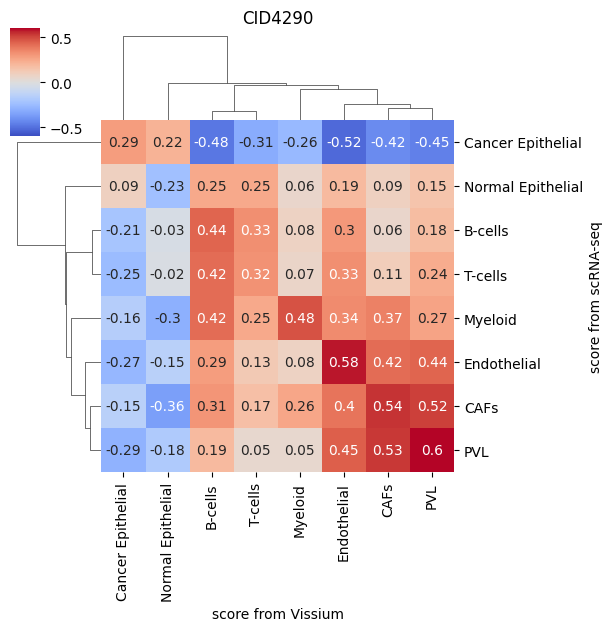

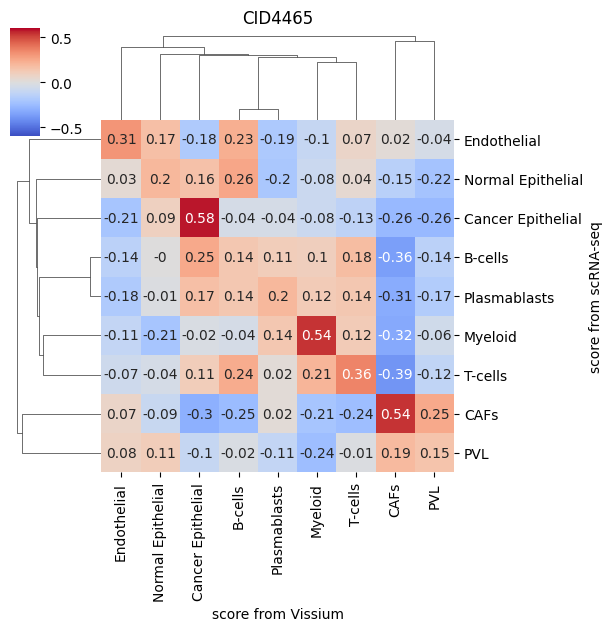

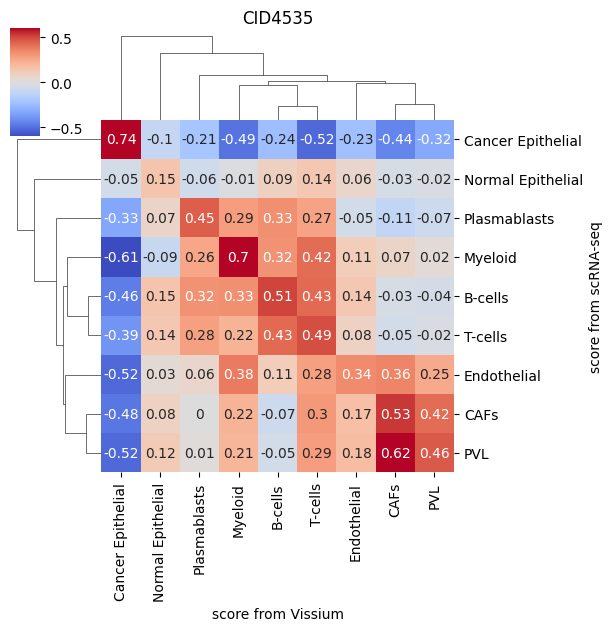

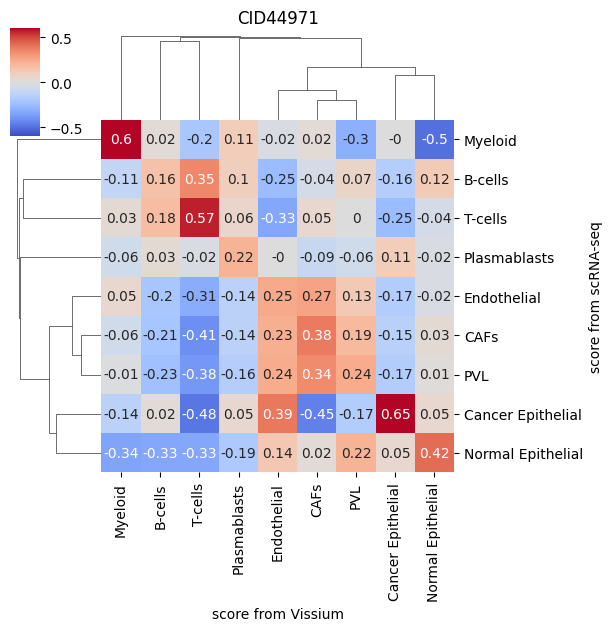

In [45]:
for sample in ["CID4290", "CID4465", "CID4535", "CID44971"]:
    df1=pd.DataFrame([st_scores[x].get(sample) for x in st_scores.keys() if st_scores[x].get(sample) is not None]).T
    df2=pd.DataFrame([sc_scores[x].get(sample) for x in sc_scores.keys() if sc_scores[x].get(sample) is not None]).T

    df2=(df2-df2.mean())/df2.std()
    df1=(df1-df1.mean())/df1.std()

    from scipy.cluster.hierarchy import linkage

    link_mat=linkage(df2.T, metric='correlation')

    cg=sns.clustermap((df2.T.dot(df1)/df1.shape[0]).round(2),row_linkage=link_mat, col_linkage=link_mat, annot=True, cmap="coolwarm", center=0, vmax=0.6, vmin=-0.6, figsize=(6,6))
    cg.ax_col_dendrogram.set_title(sample)
    cg.ax_heatmap.set_xlabel("score from Vissium")
    cg.ax_heatmap.set_ylabel("score from scRNA-seq")


In [40]:
a

AttributeError: 'ClusterGrid' object has no attribute 'ax'

/var/folders/t6/876nj23922g7ync9x5slmd0h0000gq/T/ipykernel_2976/1207366150.py:42: FutureWarning: arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.
  all_pos = np.vstack(pos.values())


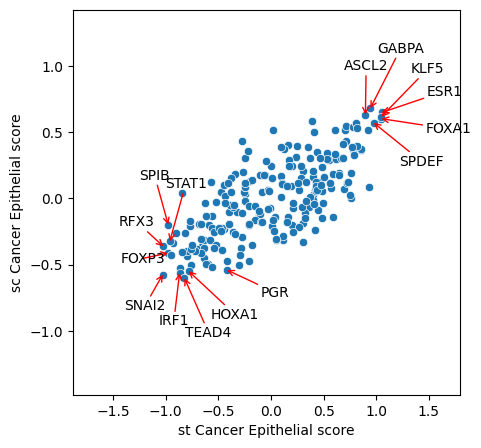

In [12]:
x=adata_st.varm['ct_scores']['Cancer Epithelial']
y=adata_sc.varm['ct_scores']['Cancer Epithelial']
plt.figure(figsize=(5,5))
ax=sns.scatterplot(x=x,y=y)
ax.set_xlabel("st Cancer Epithelial score")
ax.set_ylabel("sc Cancer Epithelial score")

tfs=np.unique([*x.sort_values().tail(5).index.to_list(),
               *x.sort_values().head(5).index.to_list(),
               *y.sort_values().tail(5).index.to_list(),
               *y.sort_values().head(5).index.to_list()])
repel_labels(ax, x.loc[tfs].to_numpy(), y.loc[tfs].to_numpy(), tfs, k=0.2)

<ipython-input-15-ac69443f999f>:40: FutureWarning: arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.
  all_pos = np.vstack(pos.values())


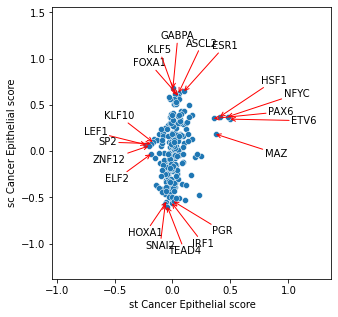

In [50]:
# x=adata_st.varm['ct_scores_stl']['Cancer Epithelial'].clip(-1,0.5)
#
# y=adata_sc.varm['ct_scores']['Cancer Epithelial']
# plt.figure(figsize=(5,5))
# ax=sns.scatterplot(x=x,y=y)
# ax.set_xlabel("st Cancer Epithelial score")
# ax.set_ylabel("sc Cancer Epithelial score")
#
# tfs=np.unique([*x.sort_values().tail(5).index.to_list(),
#                *x.sort_values().head(5).index.to_list(),
#                *y.sort_values().tail(5).index.to_list(),
#                *y.sort_values().head(5).index.to_list()])
#
# # for tf in tfs:
# #     ax.text(x.loc[tf], y.loc[tf], tf)
# repel_labels(ax, x.loc[tfs].to_numpy(), y.loc[tfs].to_numpy(), tfs, k=0.2)

In [13]:
from scipy.stats import spearmanr
pd.DataFrame({ "sc vs stl": {ct: round(spearmanr(adata_sc.varm['ct_scores'][ct], adata_st.varm['ct_scores_stl'][ct])[0],2) for ct in adata_st.varm['ct_scores_stl'].columns},
  "sc vs stan":{ct:  round(spearmanr(adata_sc.varm['ct_scores'][ct], adata_st.varm['ct_scores'][ct])[0],2) for ct in adata_st.varm['ct_scores'].columns}})

,sc vs stl,sc vs stan
B-cells,0.17,0.49
CAFs,0.33,0.51
Cancer Epithelial,0.34,0.73
Endothelial,0.16,0.32
Myeloid,0.30,0.62
Normal Epithelial,0.07,0.16
PVL,0.28,0.42
Plasmablasts,0.13,0.42
T-cells,0.17,0.46
